In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
x = np.array([1, 2, 3, 4])
y = np.array([2, 2.8, 3.6, 4.5])

In [3]:
w = 0
b = 0
alpha = 0.001
num_iterations = 100

In [4]:
sse_value = []
for i in range(num_iterations):
    y_hat = w * x + b
    D_w = (2 *np.sum((y_hat - y) * x))
    D_b = (2 *np.sum(y_hat - y) * 1)
    w = w - alpha * D_w
    b = b - alpha * D_b
    sse = (np.sum((y_hat - y)**2))
    sse_value.append(sse)
    if(i+1) % 100 == 0:
        print(f"Iteration {i+1}: w = {w}, b = {b}, SSE = {sse}")


Iteration 100: w = 1.06356303646273, b = 0.45972765199585214, SSE = 0.32178178914689


In [5]:
y_new = w * x + b
y_new

array([1.52329069, 2.58685372, 3.65041676, 4.7139798 ])

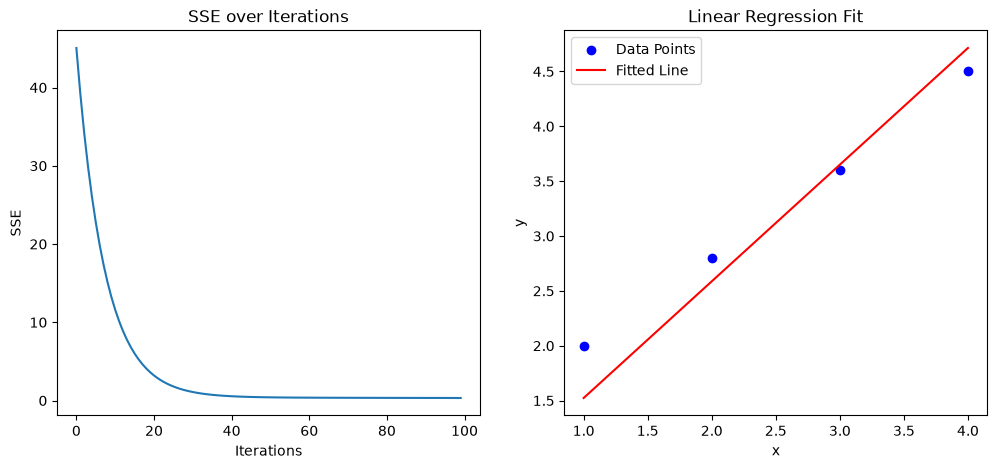

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iterations), sse_value, label='SSE')
plt.xlabel('Iterations')
plt.ylabel('SSE')
plt.title('SSE over Iterations')

plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, y_new, color='red', label='Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [7]:
import pandas as pd
df = pd.read_csv("Salary_data.csv")

In [8]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


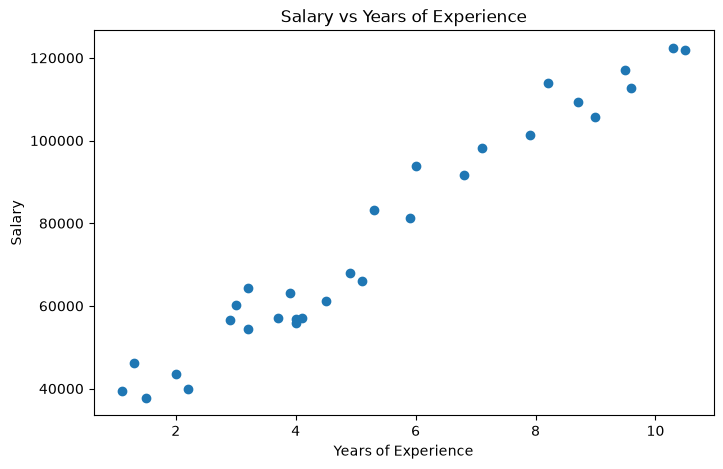

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.show()

In [10]:
x = df.iloc[:, :-1]
y = df.iloc[:, 1]

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [12]:
linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


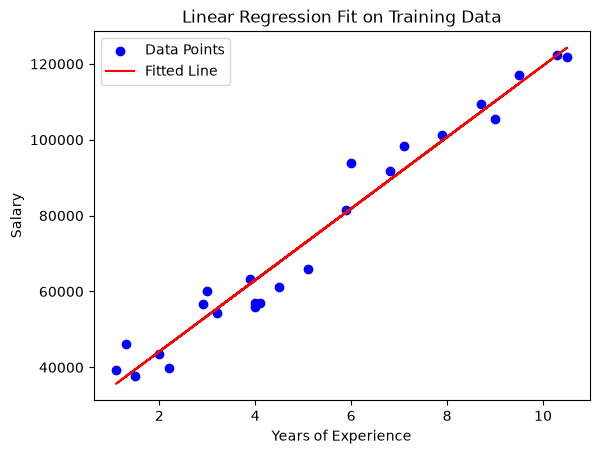

In [13]:
plt.scatter(x_train, y_train, color='blue', label='Data Points')
plt.plot(x_train, linear_reg.predict(x_train), color='red', label='Fitted Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Fit on Training Data')
plt.legend()
plt.show()

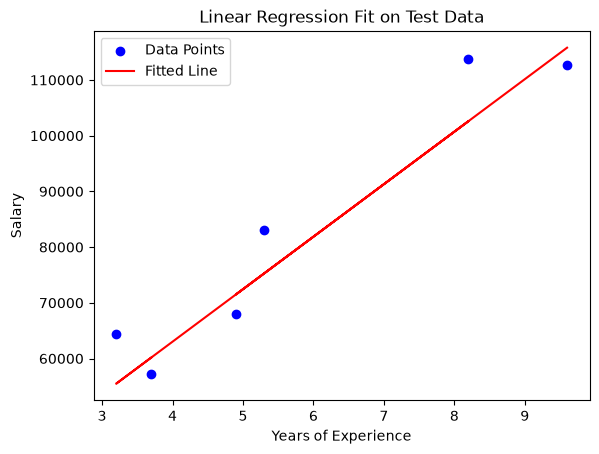

In [14]:
plt.scatter(x_test, y_test, color='blue', label='Data Points')
plt.plot(x_test, linear_reg.predict(x_test), color='red', label='Fitted Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Fit on Test Data')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = linear_reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
root_mse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {root_mse}")


Mean Squared Error: 49830096.85590839
R-squared: 0.9024461774180497
Root Mean Squared Error: 7059.04362190151


In [16]:
b, w = linear_reg.intercept_, linear_reg.coef_
print(f"Intercept (b): {b}")
print(f"Coefficient (w): {w[0]}")

Intercept (b): 25321.583011776813
Coefficient (w): 9423.815323030976


In [17]:
y_hat = w * 1.1 + b
y_hat

array([35687.77986711])